# 03 · Exploratory Data Analysis

Variables one at a time, then against vital status, with effect sizes and multiple-testing correction.

Two caveats. Associations here are not causal. Crude death rates also mix prognosis with follow-up length; notebook 04 repeats the key comparisons with Kaplan–Meier curves.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.plots import set_style, save_fig, STATUS_COLORS, PALETTE

set_style()
df = load_clean()
df["age_group"] = pd.cut(df.age, [29, 39, 49, 59, 69], labels=["30-39", "40-49", "50-59", "60-69"])
df["node_ratio"] = df.nodes_positive / df.nodes_examined
print(df.shape)

(4024, 18)


## 1. Univariate: numeric variables

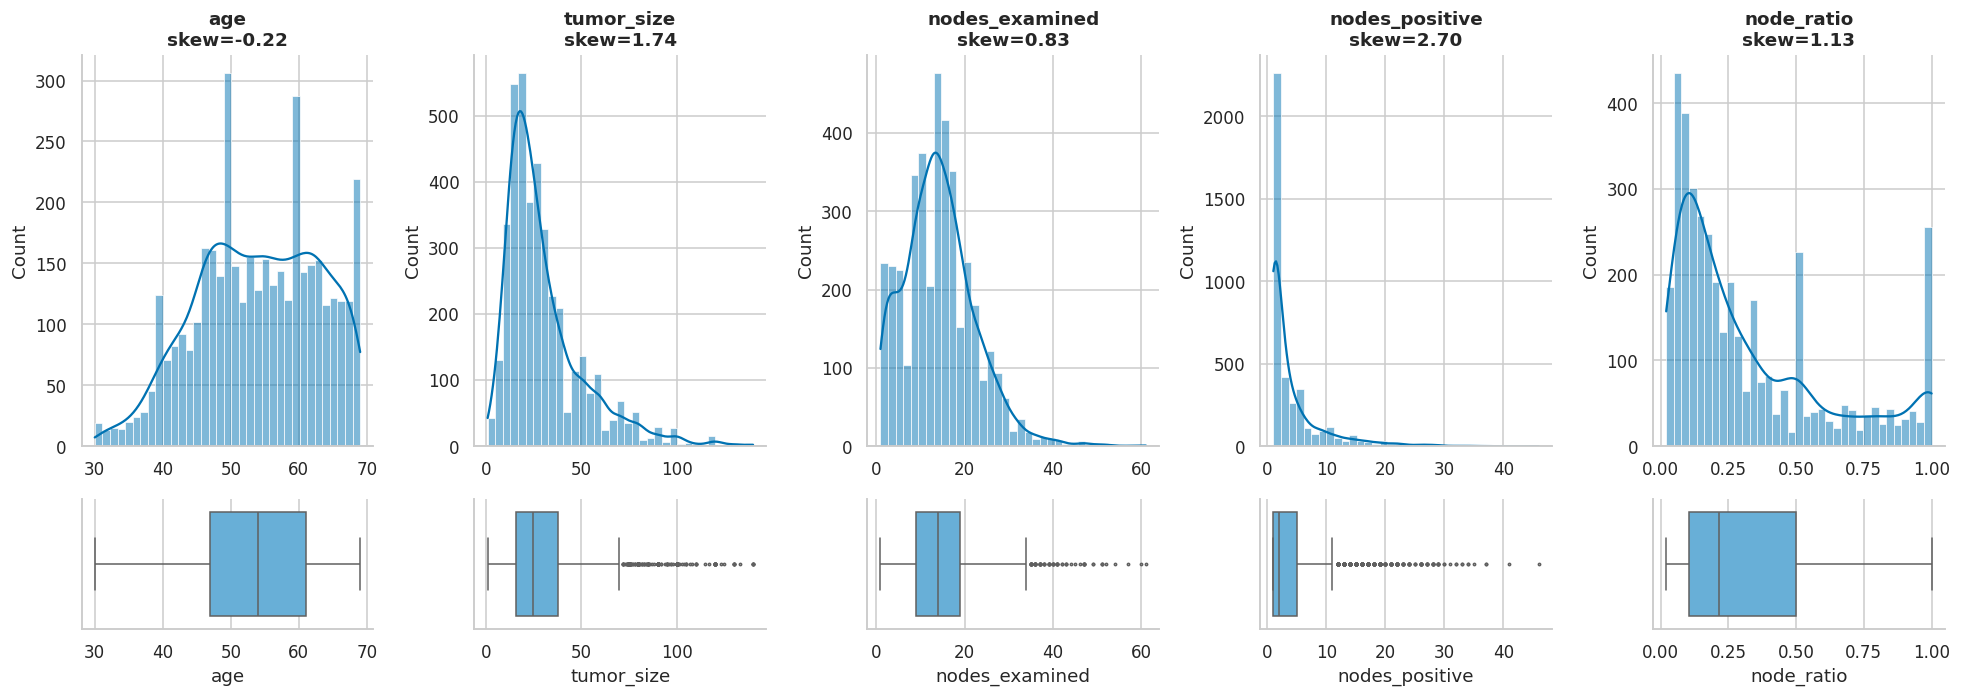

In [2]:
num_cols = C.NUMERIC_COLS + ["node_ratio"]
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 6.5), gridspec_kw={"height_ratios": [3, 1]})
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, bins=35, ax=axes[0, i], color=PALETTE[0])
    axes[0, i].set_title(f"{c}\nskew={df[c].skew():.2f}")
    axes[0, i].set_xlabel("")
    sns.boxplot(x=df[c], ax=axes[1, i], color=PALETTE[5], fliersize=1.5)
fig.tight_layout(); save_fig(fig, "03_univariate_numeric"); plt.show()

## 2. Univariate: categorical variables

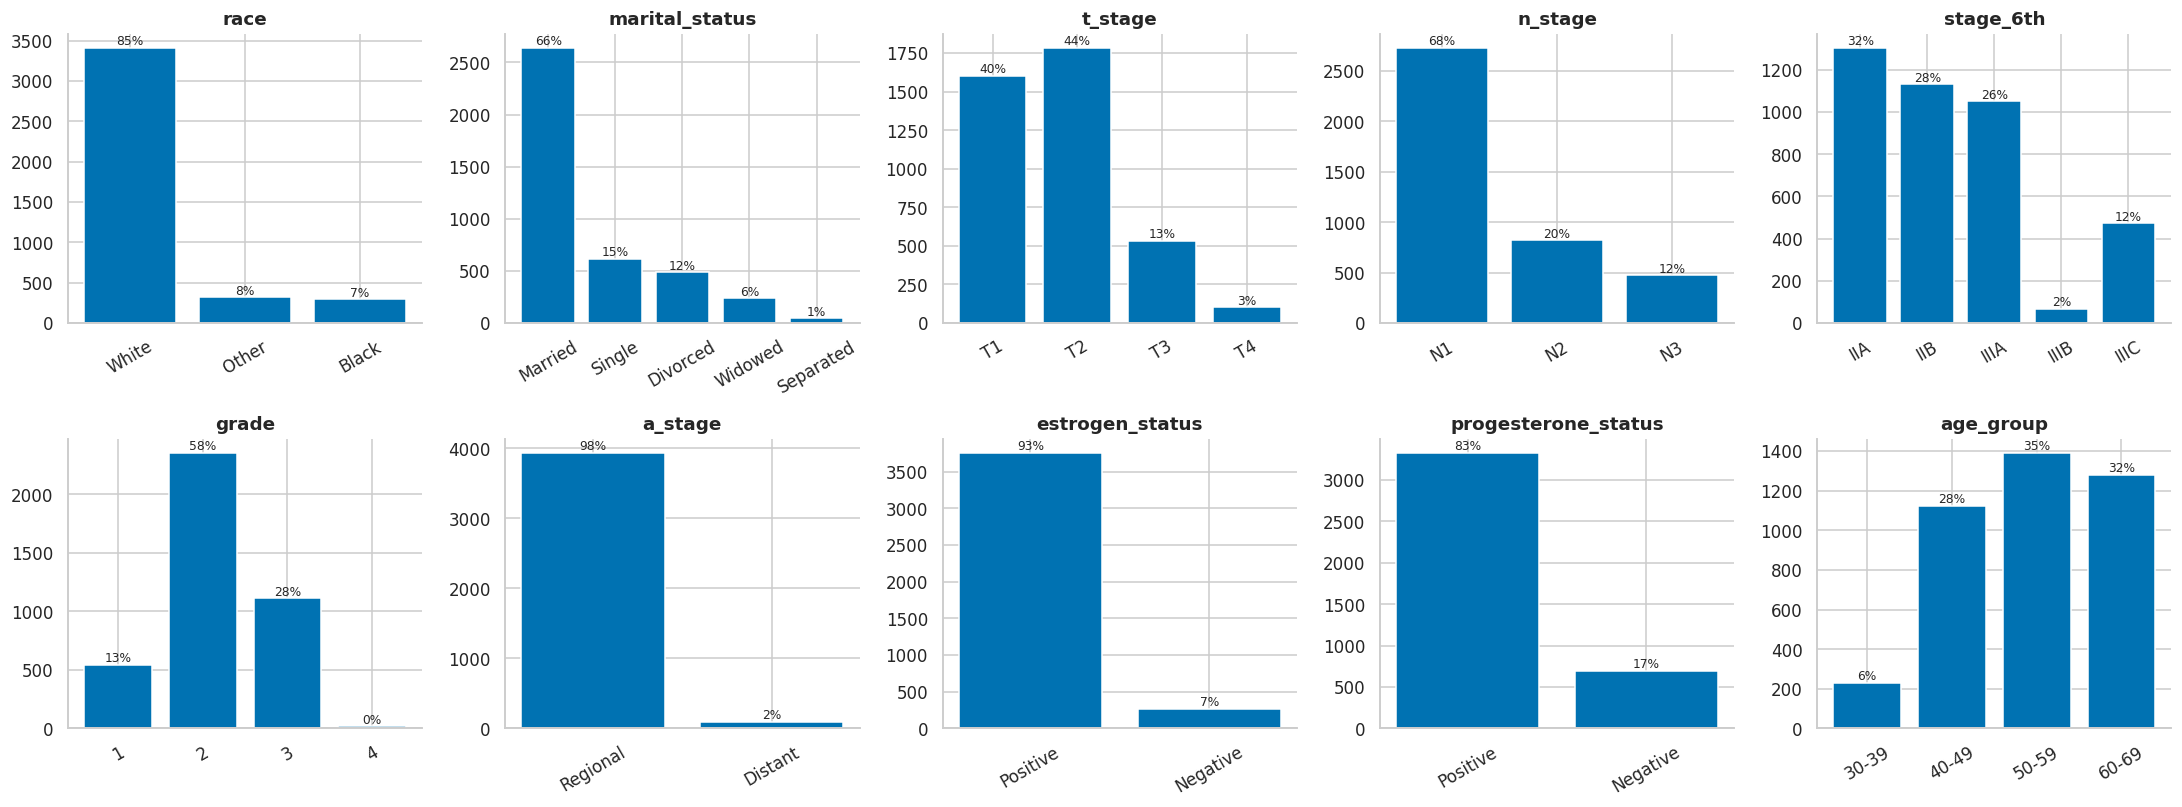

In [3]:
cat_cols = ["race", "marital_status", "t_stage", "n_stage", "stage_6th", "grade", "a_stage",
            "estrogen_status", "progesterone_status", "age_group"]
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, c in zip(axes.ravel(), cat_cols):
    order = C.ORDINAL_LEVELS.get(c, None) or (df[c].cat.categories if hasattr(df[c], "cat") else df[c].value_counts().index)
    vc = df[c].value_counts().reindex(order)
    ax.bar(vc.index.astype(str), vc.values, color=PALETTE[0])
    for j, v in enumerate(vc.values):
        ax.text(j, v, f"{v/len(df):.0%}", ha="center", va="bottom", fontsize=8)
    ax.set_title(c); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); save_fig(fig, "03_univariate_categorical"); plt.show()

Small groups to keep in mind: Grade IV (19), T4 (102), Separated (45), stage IIIB (67), Distant (92), ER-negative (269). The cohort is 85 % White, so subgroup performance is checked in notebook 09.

## 3. Bivariate: crude death rate by category (with 95 % Wilson CIs)

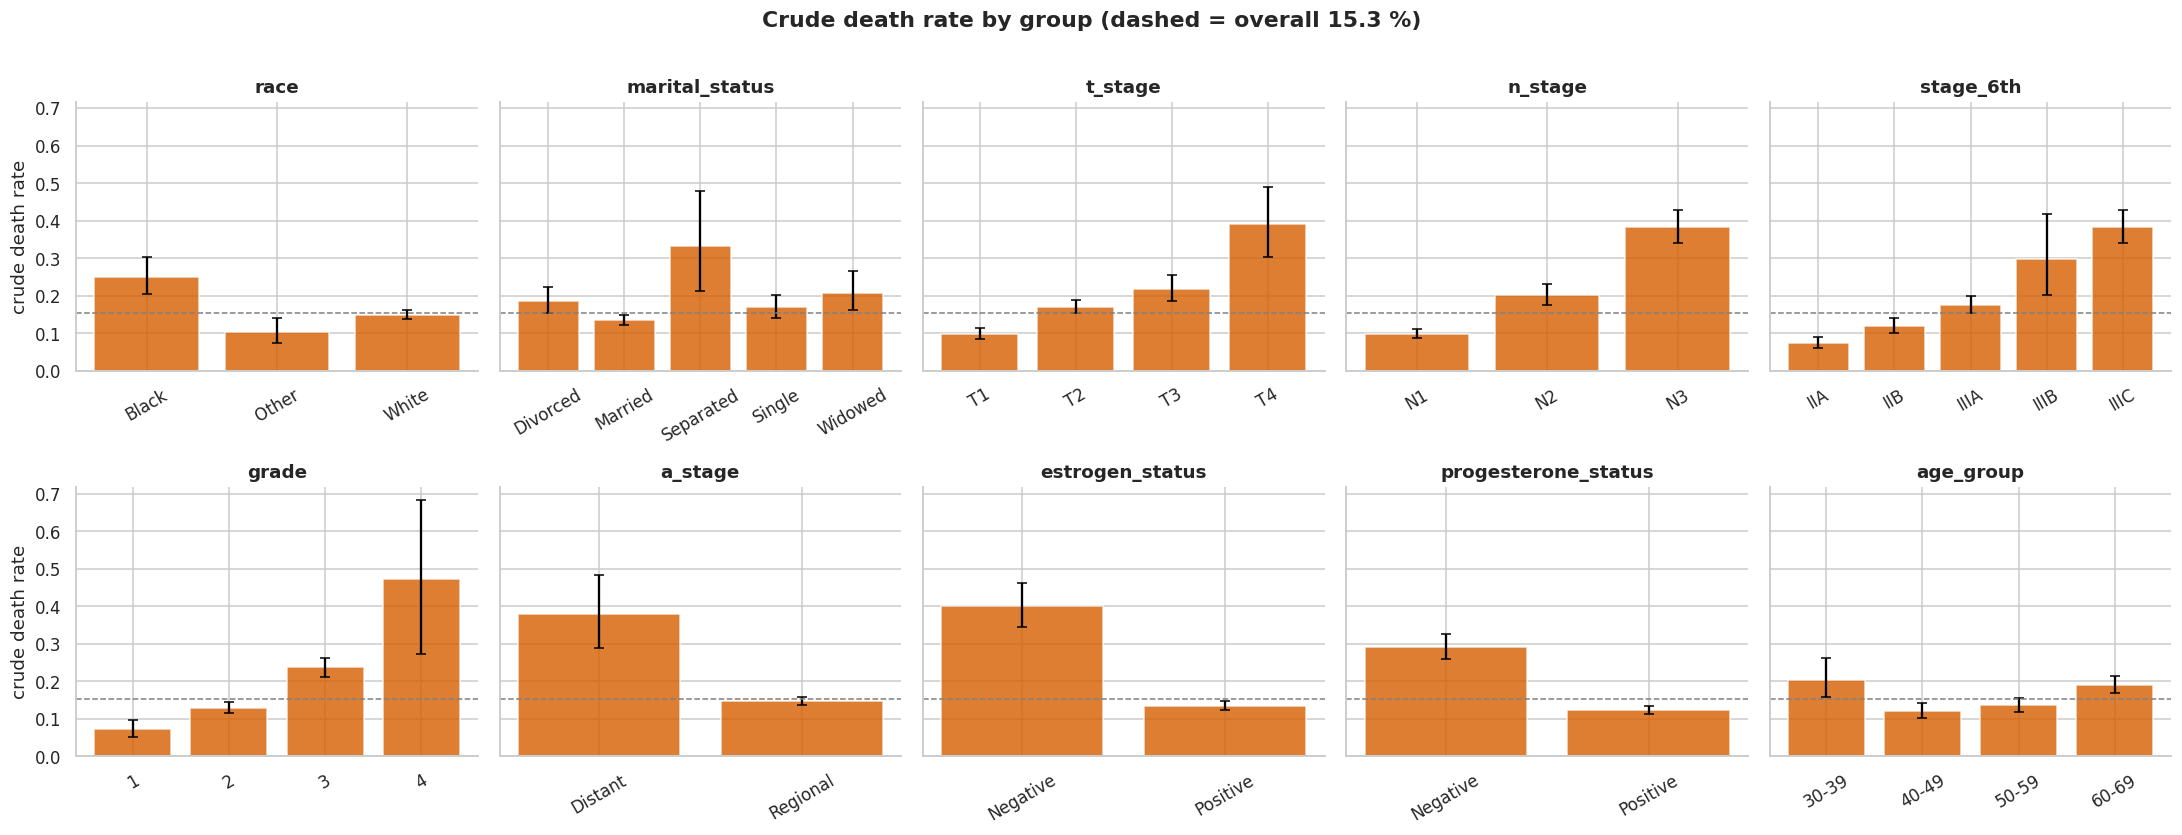

In [4]:
def rate_table(col):
    g = df.groupby(col, observed=True)["event"].agg(["size", "sum"])
    lo, hi = proportion_confint(g["sum"], g["size"], method="wilson")
    g["rate"], g["lo"], g["hi"] = g["sum"] / g["size"], lo, hi
    order = C.ORDINAL_LEVELS.get(col)
    return g.reindex(order) if order else g

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharey=True)
for ax, c in zip(axes.ravel(), cat_cols):
    t = rate_table(c)
    x = np.arange(len(t))
    ax.bar(x, t["rate"], color=PALETTE[1], alpha=.8)
    ax.errorbar(x, t["rate"], yerr=[t["rate"] - t["lo"], t["hi"] - t["rate"]], fmt="none", c="k", capsize=3)
    ax.set_xticks(x, t.index.astype(str), rotation=30)
    ax.axhline(df.event.mean(), ls="--", c="grey", lw=1)
    ax.set_title(c)
axes[0, 0].set_ylabel("crude death rate"); axes[1, 0].set_ylabel("crude death rate")
fig.suptitle("Crude death rate by group (dashed = overall 15.3 %)", fontweight="bold", y=1.01)
fig.tight_layout(); save_fig(fig, "03_death_rate_by_group"); plt.show()

## 4. Bivariate: numeric variables by status

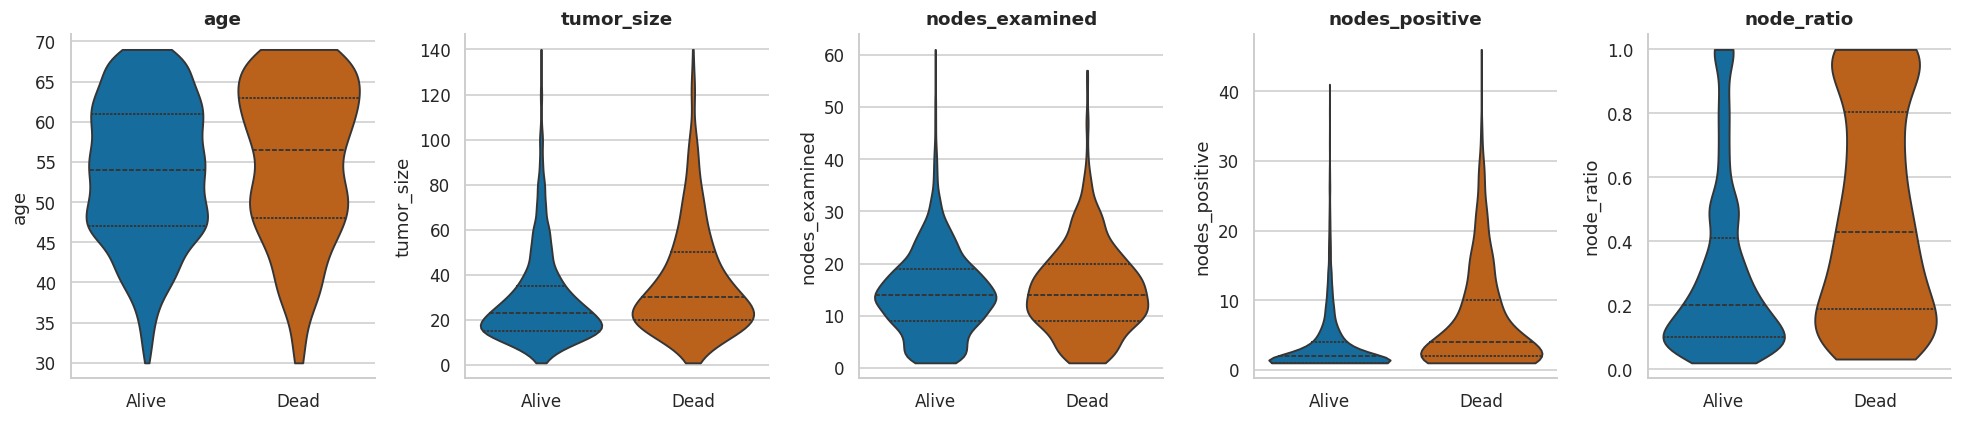

In [5]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, c in zip(axes, num_cols):
    sns.violinplot(data=df, x="status", y=c, ax=ax, palette=STATUS_COLORS, inner="quartile", cut=0)
    ax.set_title(c); ax.set_xlabel("")
fig.tight_layout(); save_fig(fig, "03_numeric_by_status"); plt.show()

## 5. Association tests

- Categorical vs status: χ² test, Cramér's V.
- Numeric vs status: Mann–Whitney U, rank-biserial r.
- Benjamini–Hochberg correction across the 15 tests.

Effect size guide (Cohen, 1988): 0.1 small, 0.3 medium, 0.5 large.

In [6]:
rows = []
for c in cat_cols:
    ct = pd.crosstab(df[c], df.status)
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
    rows.append({"variable": c, "test": "chi-square", "statistic": chi2, "p": p, "effect": v,
                 "effect_type": "Cramer's V", "min_expected": exp.min()})
for c in num_cols:
    a, b = df.loc[df.event == 1, c], df.loc[df.event == 0, c]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - 2 * u / (len(a) * len(b))          # rank-biserial, sign: + means lower in Dead
    rows.append({"variable": c, "test": "Mann-Whitney U", "statistic": u, "p": p, "effect": -r,
                 "effect_type": "rank-biserial (+ = higher in Dead)", "min_expected": np.nan})
tests = pd.DataFrame(rows)
tests["p_adj_BH"] = multipletests(tests.p, method="fdr_bh")[1]
tests["significant_FDR5%"] = tests.p_adj_BH < 0.05
tests.sort_values("effect", key=np.abs, ascending=False).round(4)

,variable,test,statistic,p,effect,effect_type,min_expected,p_adj_BH,significant_FDR5%
14,node_ratio,Mann-Whitney U,1.412386e+06,0.0000,0.3456,rank-biserial (+ = higher in Dead),NaN,0.0000,True
13,nodes_positive,Mann-Whitney U,1.406766e+06,0.0000,0.3402,rank-biserial (+ = higher in Dead),NaN,0.0000,True
4,stage_6th,chi-square,2.816484e+02,0.0000,0.2646,Cramer's V,10.2565,0.0000,True
3,n_stage,chi-square,2.699291e+02,0.0000,0.2590,Cramer's V,72.2545,0.0000,True
11,tumor_size,Mann-Whitney U,1.286092e+06,0.0000,0.2252,rank-biserial (+ = higher in Dead),NaN,0.0000,True
7,estrogen_status,chi-square,1.351557e+02,0.0000,0.1833,Cramer's V,41.1789,0.0000,True
8,progesterone_status,chi-square,1.248854e+02,0.0000,0.1762,Cramer's V,106.8509,0.0000,True
5,grade,chi-square,1.125563e+02,0.0000,0.1672,Cramer's V,2.9085,0.0000,True
2,t_stage,chi-square,1.034763e+02,0.0000,0.1604,Cramer's V,15.6143,0.0000,True
10,age,Mann-Whitney U,1.154823e+06,0.0001,0.1002,rank-biserial (+ = higher in Dead),NaN,0.0001,True


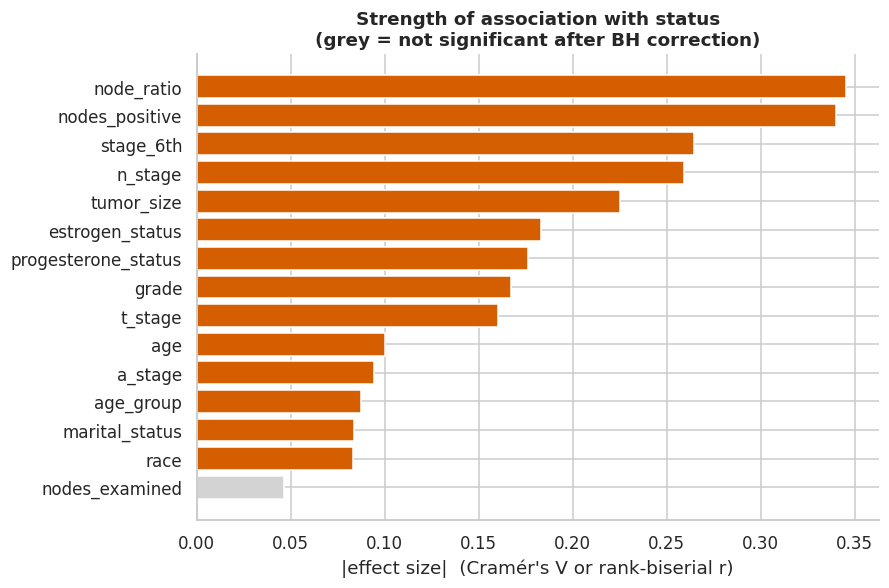

In [7]:
t = tests.assign(abs_effect=tests.effect.abs()).sort_values("abs_effect")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(t.variable, t.abs_effect, color=np.where(t["significant_FDR5%"], PALETTE[1], "lightgrey"))
ax.set_xlabel("|effect size|  (Cramér's V or rank-biserial r)")
ax.set_title("Strength of association with status\n(grey = not significant after BH correction)")
save_fig(fig, "03_effect_sizes"); plt.show()

## 6. Joint effect of T and N (the core of AJCC staging)

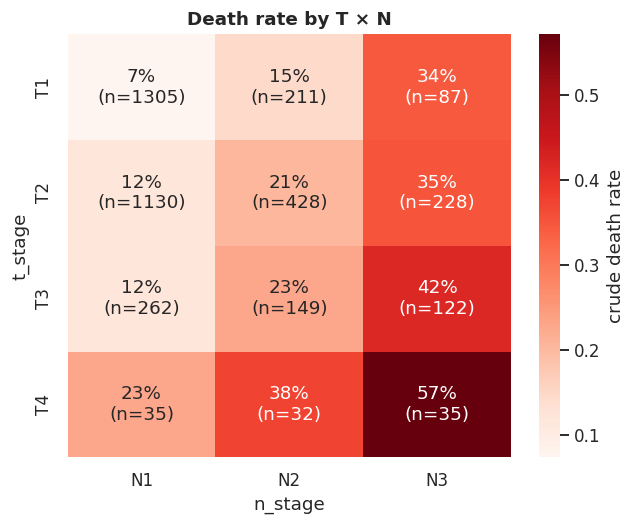

In [8]:
piv_rate = df.pivot_table(index="t_stage", columns="n_stage", values="event", aggfunc="mean")
piv_n = df.pivot_table(index="t_stage", columns="n_stage", values="event", aggfunc="size")
annot = piv_rate.map(lambda v: f"{v:.0%}") + "\n(n=" + piv_n.astype(str) + ")"
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(piv_rate, annot=annot, fmt="", cmap="Reds", cbar_kws={"label": "crude death rate"}, ax=ax)
ax.set_title("Death rate by T × N")
save_fig(fig, "03_t_by_n_heatmap"); plt.show()

## 7. Hormone receptors and grade

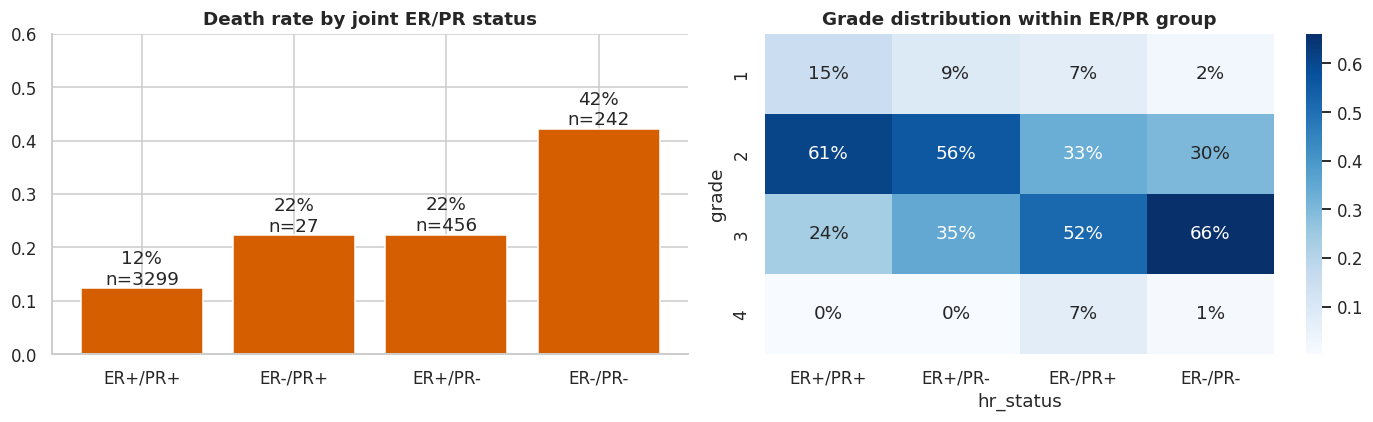

In [9]:
er = df.estrogen_status.map({"Positive": "ER+", "Negative": "ER-"})
pr = df.progesterone_status.map({"Positive": "PR+", "Negative": "PR-"})
df["hr_status"] = er + "/" + pr
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t = df.groupby("hr_status")["event"].agg(["mean", "size"]).sort_values("mean")
axes[0].bar(t.index, t["mean"], color=PALETTE[1])
for i, (m, n) in enumerate(zip(t["mean"], t["size"])):
    axes[0].text(i, m, f"{m:.0%}\nn={n}", ha="center", va="bottom")
axes[0].set_title("Death rate by joint ER/PR status"); axes[0].set_ylim(0, .6)
sns.heatmap(pd.crosstab(df.grade, df.hr_status, normalize="columns"), annot=True, fmt=".0%", cmap="Blues", ax=axes[1])
axes[1].set_title("Grade distribution within ER/PR group")
fig.tight_layout(); save_fig(fig, "03_hormone_grade"); plt.show()

## 8. Correlation among predictors (Spearman, ordinal variables coded as integers)

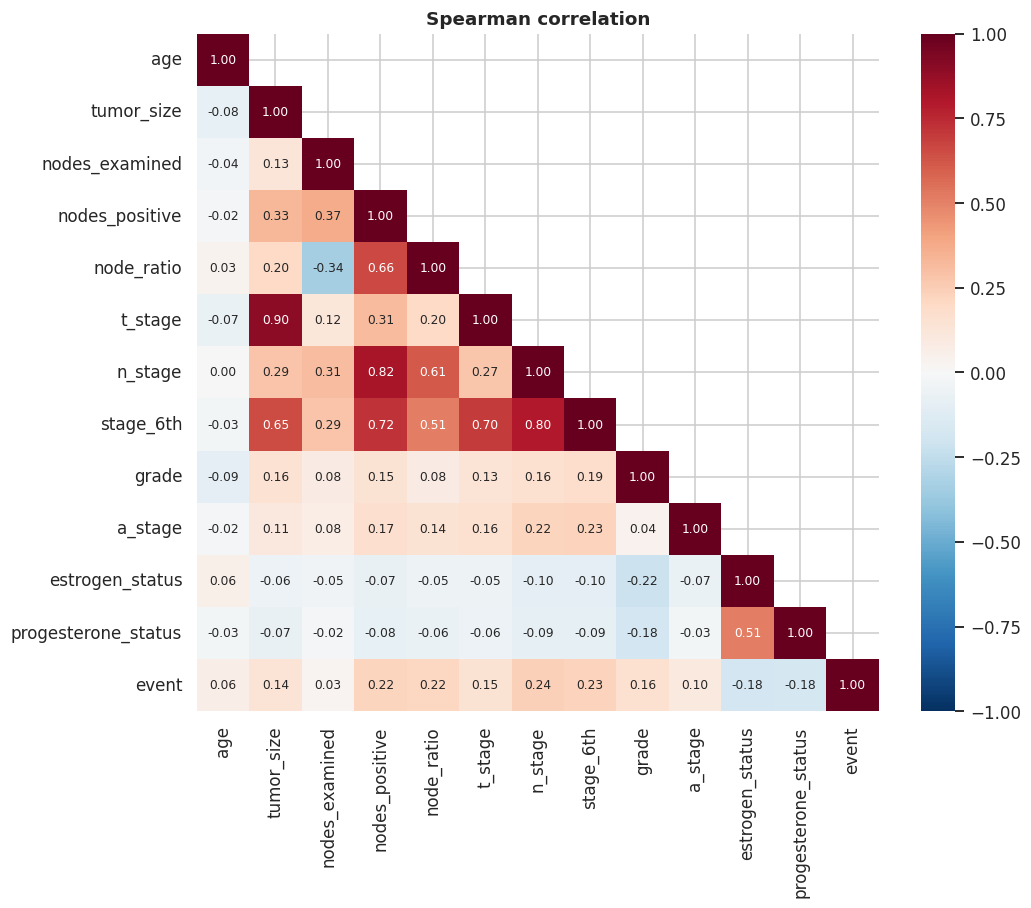

In [10]:
enc = df.copy()
for c in ["t_stage", "n_stage", "stage_6th"]:
    enc[c] = enc[c].map({v: i for i, v in enumerate(C.ORDINAL_LEVELS[c], 1)})
for c, pos in [("estrogen_status", "Positive"), ("progesterone_status", "Positive"), ("a_stage", "Distant")]:
    enc[c] = (enc[c] == pos).astype(int)
corr_cols = ["age", "tumor_size", "nodes_examined", "nodes_positive", "node_ratio", "t_stage", "n_stage",
             "stage_6th", "grade", "a_stage", "estrogen_status", "progesterone_status", "event"]
corr = enc[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool), 1), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
ax.set_title("Spearman correlation")
save_fig(fig, "03_spearman"); plt.show()

Pairs with |ρ| > 0.7 point to redundancy:

In [11]:
pairs = corr.where(np.triu(np.ones_like(corr, bool), 1)).stack().rename("rho").reset_index()
pairs[pairs.rho.abs() > 0.7].sort_values("rho", key=np.abs, ascending=False)

,level_0,level_1,rho
15,tumor_size,t_stage,0.895311
35,nodes_positive,n_stage,0.821435
57,n_stage,stage_6th,0.801472
36,nodes_positive,stage_6th,0.724660


## 9. Multicollinearity check (VIF)

VIF > 10 is a common warning level (Kutner et al., *Applied Linear Statistical Models*, 5th ed.). Computed on candidate linear-model inputs, **with and without** `stage_6th`.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

def vif_table(cols):
    X = add_constant(enc[cols].astype(float))
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=cols).round(2)

base = ["age", "tumor_size", "nodes_examined", "nodes_positive", "t_stage", "n_stage", "grade",
        "a_stage", "estrogen_status", "progesterone_status"]
pd.DataFrame({"with stage_6th": vif_table(base + ["stage_6th"]), "without stage_6th": vif_table(base)})

,with stage_6th,without stage_6th
a_stage,1.12,1.12
age,1.02,1.02
estrogen_status,1.40,1.40
grade,1.10,1.09
n_stage,9.78,3.51
nodes_examined,1.21,1.21
nodes_positive,3.76,3.62
progesterone_status,1.38,1.38
stage_6th,13.21,NaN
t_stage,5.53,3.04


## 10. Mutual information with status (captures non-linear dependence)

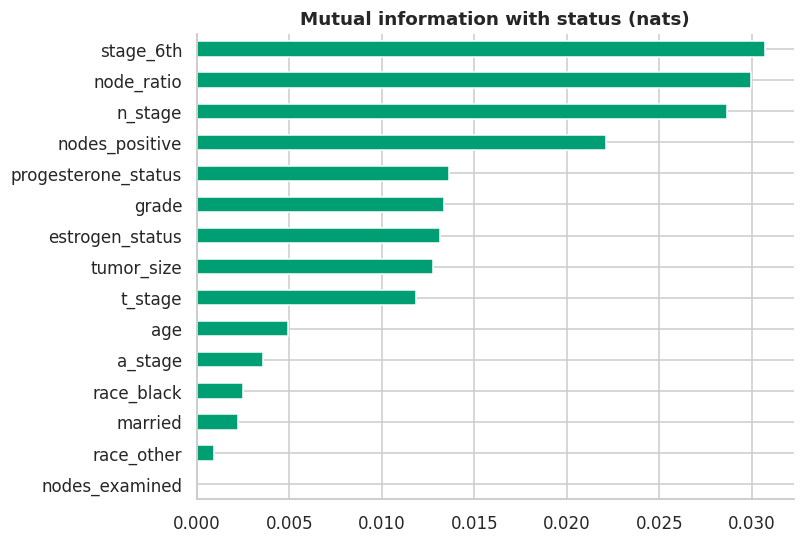

In [13]:
from sklearn.feature_selection import mutual_info_classif
mi_cols = [c for c in corr_cols if c != "event"] + ["race_black", "race_other", "married"]
enc["race_black"] = (df.race == "Black").astype(int)
enc["race_other"] = (df.race == "Other").astype(int)
enc["married"] = (df.marital_status == "Married").astype(int)
discrete = [enc[c].nunique() < 10 for c in mi_cols]
mi = mutual_info_classif(enc[mi_cols], enc.event, discrete_features=discrete, random_state=C.RANDOM_STATE)
mi = pd.Series(mi, index=mi_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 5.5))
mi.plot.barh(ax=ax, color=PALETTE[2]); ax.set_title("Mutual information with status (nats)")
save_fig(fig, "03_mutual_information"); plt.show()

## 11. Age: linear or not?

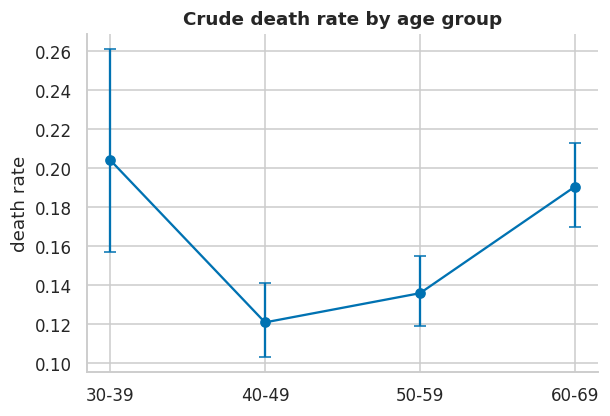

,size,sum,rate,lo,hi
age_group,,,,,
30-39,230,47,0.204,0.157,0.261
40-49,1124,136,0.121,0.103,0.141
50-59,1390,189,0.136,0.119,0.155
60-69,1280,244,0.191,0.170,0.213


In [14]:
t = rate_table("age_group")
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(t.index.astype(str), t["rate"], yerr=[t["rate"] - t["lo"], t["hi"] - t["rate"]], marker="o", capsize=4)
ax.set_title("Crude death rate by age group"); ax.set_ylabel("death rate")
save_fig(fig, "03_age_groups"); plt.show()
t.round(3)

## Findings

- Nodal burden is the strongest signal: `node_ratio` r = 0.35, `nodes_positive` r = 0.34, `n_stage` V = 0.26.
- Tumour size (r = 0.23), ER (V = 0.18), PR (V = 0.18) and grade (V = 0.17) follow.
- Crude death rate by age is U-shaped: 20.4 % (30–39), 12.1 % (40–49), 13.6 % (50–59), 19.1 % (60–69). The youngest group is small (n = 230).
- Race and marital status show small differences (V ≈ 0.08). These are likely confounded by stage and receptor status.
- `nodes_examined` alone is not associated (adjusted p > 0.05).
- `tumor_size`–`t_stage` ρ = 0.90 and `nodes_positive`–`n_stage` ρ = 0.82. The VIF of `n_stage` drops from 9.8 to 3.5 without `stage_6th`.
- Grade IV has only 19 patients, so its χ² expected count is below 5.

Tested next in notebook 05: does node ratio add information, and does a non-linear age term help?